In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from tqdm import tqdm
from PIL import Image as PILImage
from scipy.stats import pearsonr, spearmanr

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [2]:
CSV_PATH   = "data.csv"
IMAGE_DIR  = "AGIQA-3K/"
CHECKPOINT = "checkpoints/best_pretrained_model.pth"
IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS     = 50
LR         = 1e-4
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"

os.makedirs("checkpoints", exist_ok=True)
print(f"Device: {DEVICE}")

Device: cuda


In [3]:
class AGIQADataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, row["name"])
        image    = PILImage.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        mos = torch.tensor(row["mos_quality"], dtype=torch.float32)
        return image, mos


mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

val_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

df = pd.read_csv(CSV_PATH)[["name", "mos_quality"]].dropna()
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

n       = len(df)
n_test  = int(n * 0.15)
n_val   = int(n * 0.15)
n_train = n - n_val - n_test

train_df = df.iloc[:n_train]
val_df   = df.iloc[n_train : n_train + n_val]
test_df  = df.iloc[n_train + n_val :]

train_loader = DataLoader(AGIQADataset(train_df, IMAGE_DIR, train_tf),
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(AGIQADataset(val_df, IMAGE_DIR, val_tf),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(AGIQADataset(test_df, IMAGE_DIR, val_tf),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Split -- Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")

Split -- Train: 2088  Val: 447  Test: 447


In [4]:
class PretrainedIQA(nn.Module):
    """Pretrained ResNet-50 backbone with a regression head."""

    def __init__(self, dropout=0.4):
        super().__init__()
        backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.features = nn.Sequential(*list(backbone.children())[:-1])
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(2048, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout / 2),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        x = self.features(x)
        return self.head(x).squeeze(-1)


model     = PretrainedIQA(dropout=0.4).to(DEVICE)
criterion = nn.SmoothL1Loss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

total = sum(p.numel() for p in model.parameters())
train_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total:,}  Trainable: {train_p:,}")

Total params: 24,622,913  Trainable: 24,622,913


In [5]:
history = {"train_loss": [], "val_loss": [], "val_srcc": [], "val_plcc": []}
best_val_srcc = -1.0

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss, num_samples = 0.0, 0
    for images, scores in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [train]"):
        images, scores = images.to(DEVICE), scores.to(DEVICE)
        optimizer.zero_grad()
        preds = model(images)
        loss  = criterion(preds, scores)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        num_samples  += images.size(0)

    model.eval()
    val_running, val_n = 0.0, 0
    all_preds, all_gt = [], []
    with torch.no_grad():
        for images, scores in tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [val]  "):
            images, scores = images.to(DEVICE), scores.to(DEVICE)
            preds = model(images)
            val_running += criterion(preds, scores).item() * images.size(0)
            val_n       += images.size(0)
            all_preds.append(preds.cpu().numpy())
            all_gt.append(scores.cpu().numpy())

    train_loss = running_loss / num_samples
    val_loss   = val_running / val_n
    p_arr = np.concatenate(all_preds)
    g_arr = np.concatenate(all_gt)
    val_srcc, _ = spearmanr(p_arr, g_arr)
    val_plcc, _ = pearsonr(p_arr, g_arr)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_srcc"].append(val_srcc)
    history["val_plcc"].append(val_plcc)

    cur_lr = optimizer.param_groups[0]["lr"]
    scheduler.step()

    print(f"Epoch {epoch:3d} | Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | SRCC: {val_srcc:.4f} | "
          f"PLCC: {val_plcc:.4f} | LR: {cur_lr:.2e}")

    if val_srcc > best_val_srcc:
        best_val_srcc = val_srcc
        torch.save({"epoch": epoch, "model_state": model.state_dict(),
                    "val_srcc": val_srcc}, CHECKPOINT)
        print(f"  -> Saved best model (SRCC={val_srcc:.4f})")

print("Training complete!")

Epoch 1/50 [val]  : 100%|██████████| 14/14 [00:00<00:00, 20.24it/s]


Epoch   1 | Loss: 0.7076 | Val Loss: 0.2394 | SRCC: 0.6968 | PLCC: 0.7264 | LR: 1.00e-04
  -> Saved best model (SRCC=0.6968)


Epoch 2/50 [val]  : 100%|██████████| 14/14 [00:00<00:00, 20.32it/s]


Epoch   2 | Loss: 0.2092 | Val Loss: 0.1891 | SRCC: 0.7443 | PLCC: 0.7954 | LR: 9.99e-05
  -> Saved best model (SRCC=0.7443)


Epoch 3/50 [val]  : 100%|██████████| 14/14 [00:00<00:00, 20.11it/s]


...

Epoch  48 | Loss: 0.0296 | Val Loss: 0.1107 | SRCC: 0.8395 | PLCC: 0.8930 | LR: 1.88e-06


Epoch 49/50 [val]  : 100%|██████████| 14/14 [00:00<00:00, 20.24it/s]


Epoch  49 | Loss: 0.0311 | Val Loss: 0.1098 | SRCC: 0.8396 | PLCC: 0.8940 | LR: 1.39e-06


Epoch 50/50 [val]  : 100%|██████████| 14/14 [00:00<00:00, 19.95it/s]

Epoch  50 | Loss: 0.0309 | Val Loss: 0.1091 | SRCC: 0.8414 | PLCC: 0.8945 | LR: 1.10e-06
Training complete!


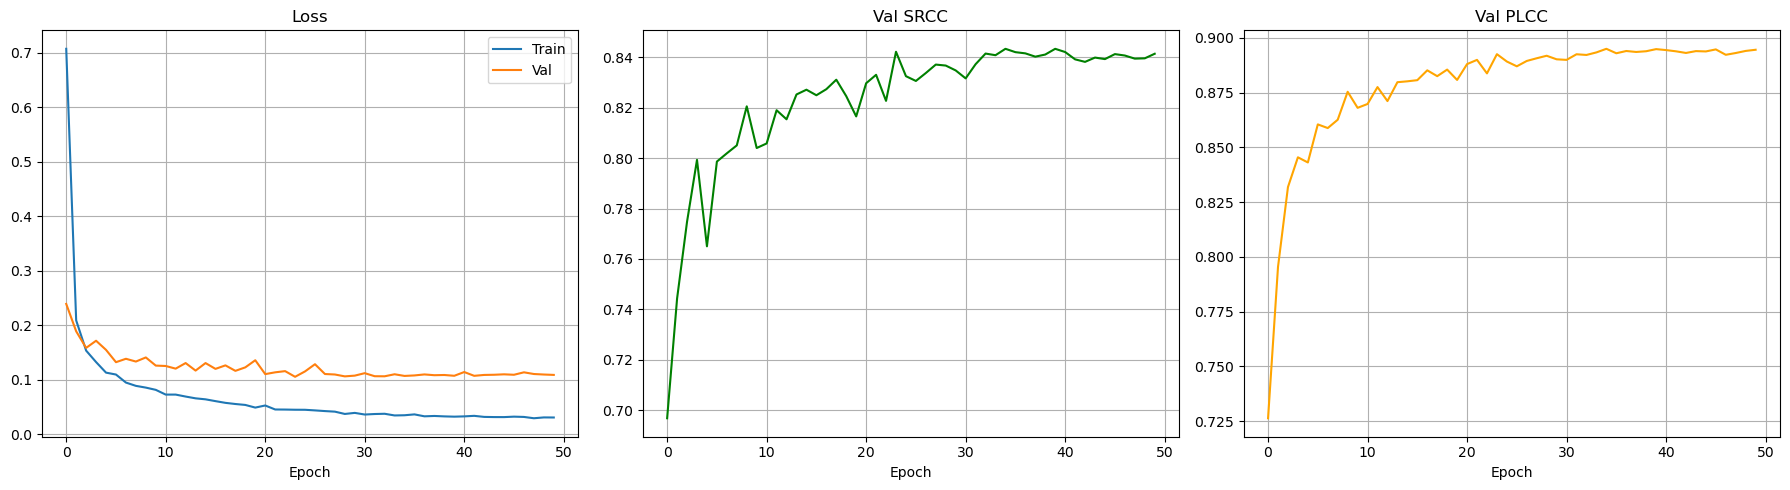

In [6]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

ax1.plot(history["train_loss"], label="Train")
ax1.plot(history["val_loss"],   label="Val")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch")
ax1.legend(); ax1.grid(True)

ax2.plot(history["val_srcc"], color="green")
ax2.set_title("Val SRCC"); ax2.set_xlabel("Epoch"); ax2.grid(True)

ax3.plot(history["val_plcc"], color="orange")
ax3.set_title("Val PLCC"); ax3.set_xlabel("Epoch"); ax3.grid(True)

plt.tight_layout()
plt.savefig("training_curves_pretrained.png")
plt.show()

Loaded best model from epoch 35 (SRCC=0.8434)



Testing: 100%|██████████| 14/14 [00:00<00:00, 20.25it/s]


Test Results (Pretrained ResNet-50)
  SRCC : 0.8463
  PLCC : 0.8970
  RMSE : 0.4525


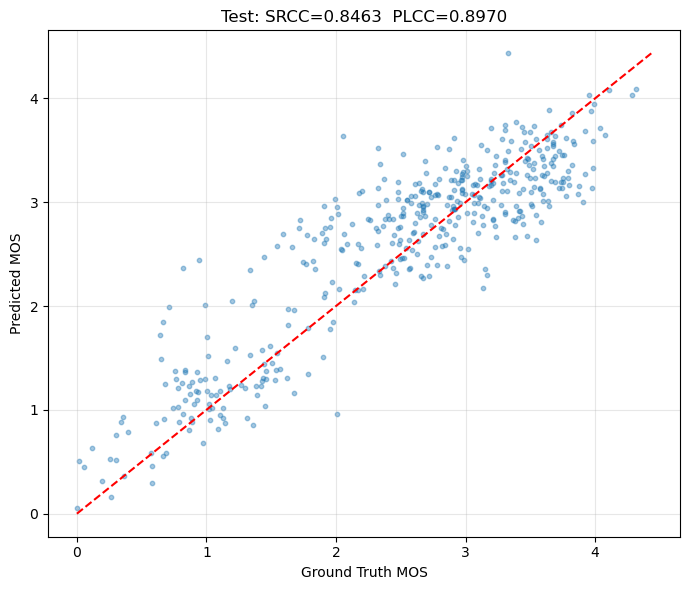

In [7]:
ckpt = torch.load(CHECKPOINT, weights_only=False)
model.load_state_dict(ckpt["model_state"])
print(f"Loaded best model from epoch {ckpt['epoch']} (SRCC={ckpt['val_srcc']:.4f})\n")

model.eval()
all_preds, all_gt = [], []
with torch.no_grad():
    for images, scores in tqdm(test_loader, desc="Testing"):
        preds = model(images.to(DEVICE)).cpu().numpy()
        all_preds.append(preds)
        all_gt.append(scores.numpy())

preds_arr = np.concatenate(all_preds)
gt_arr    = np.concatenate(all_gt)

srcc, _ = spearmanr(gt_arr, preds_arr)
plcc, _ = pearsonr(gt_arr, preds_arr)
rmse    = np.sqrt(np.mean((gt_arr - preds_arr) ** 2))

print("=" * 40)
print("Test Results (Pretrained ResNet-50)")
print("=" * 40)
print(f"  SRCC : {srcc:.4f}")
print(f"  PLCC : {plcc:.4f}")
print(f"  RMSE : {rmse:.4f}")
print("=" * 40)

plt.figure(figsize=(7, 6))
plt.scatter(gt_arr, preds_arr, alpha=0.4, s=10)
lo, hi = min(gt_arr.min(), preds_arr.min()), max(gt_arr.max(), preds_arr.max())
plt.plot([lo, hi], [lo, hi], "r--")
plt.xlabel("Ground Truth MOS")
plt.ylabel("Predicted MOS")
plt.title(f"Test: SRCC={srcc:.4f}  PLCC={plcc:.4f}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("test_scatter_pretrained.png")
plt.show()